In [17]:
import pandas as pd

In [18]:
df=pd.read_csv('../datasets/dataset_main.csv')

В итоговом датасете каждая строка соответствует одному доменному имени .ton
# Обзор признаков
### Основные 

- **domain** — доменное имя.  
  Пример: `google`, `yandex`.

- **ton_price** — целевая переменная: цена домена в сети TON.  

### Признаки, связанные с Ethereum Name Service (ENS)

- **eth_reg_price** — цена в долларах регистрации аналогичного домена в ENS
  Если аналогичный домен в ENS не найден, значение может быть пропущено.

- **eth_sales_count** — количество вторичных продаж аналогичного домена в ENS.

- **eth_sales_volume_usd** — суммарный объём вторичных продаж аналогичного домена в ENS.

- **eth_last_sale_price_usd** — цена последней зафиксированной вторичной продажи аналогичного домена в ENS.

### Признаки, связанные с Solana Name Service (SNS)

- **sol_reg_price** — цена в долларах регистрации аналогичного домена в SNS

- **sol_sales_count** — количество вторичных продаж аналогичного домена в SNS

- **sol_sales_volume_usd** — суммарный объём вторичных продаж аналогичного домена в SNS в долларах США

- **sol_last_sale_price_usd** — цена последней зафиксированной вторичной продажи аналогичного домена в SNS

### Дополнительные признаки

- **category** — категориальная или семантическая характеристика доменного имени, полученная из внешних источников.  
  Пример категорий: `Business`, `News`, `Technology`.

- **rank** — признак интернет-популярности домена, полученный из внешних рейтингов популярных сайтов.

### Простые признаки самого имени

- **has_digit** — есть ли в домене цифры.  
  `1` — да, `0` — нет.

- **has_letter** — есть ли в домене буквы.  
  `1` — да, `0` — нет.

- **has_huphen** — есть ли в домене дефис.  
  `1` — да, `0` — нет.

- **length** — длина доменного имени, то есть сколько символов в нём содержится.

### Что значат пропуски

Если в столбцах Ethereum, Solana есть пропуски - значит в истории блокчейна не было информации о продажи этого домена 

Если в столбцах `category` или `rank` есть пропуски - значит домен не популярен и его не удалось сопоставить с известными доменами

# Общая информация

In [19]:
df.shape

(69866, 16)

In [20]:
num_cols = [
    'eth_reg_price',
    'eth_sales_count',
    'eth_sales_volume_usd',
    'eth_last_sale_price_usd',
    'sol_reg_price',
    'sol_sales_count',
    'sol_sales_volume_usd',
    'sol_last_sale_price_usd',
    'ton_price',
    'rank',
    'has_digit',
    'has_letter',
    'has_hyphen',
    'length'
]

stats=df[num_cols].describe().T
stats['missing']=df[num_cols].median()
stats['median']=df[num_cols].isna().sum()

In [21]:
stats

,count,mean,std,min,25%,50%,75%,max,missing,median
eth_reg_price,67732.0,2.703079e+02,1.769280e+03,0.000000,5.470000,12.00000,28.080000,1.067147e+05,12.00000,2134
eth_sales_count,8686.0,1.569422e+00,1.152187e+00,0.000000,1.000000,1.00000,2.000000,1.300000e+01,1.00000,61180
eth_sales_volume_usd,8686.0,4.656162e+03,2.124442e+04,0.000000,134.826468,1140.83115,4715.899249,1.512378e+06,1140.83115,61180
eth_last_sale_price_usd,8682.0,3.362960e+03,2.071875e+04,0.000000,96.810397,639.12264,2654.216750,1.512378e+06,639.12264,61184
sol_reg_price,38218.0,4.491592e+01,1.262328e+02,0.596662,19.427534,20.25000,24.933793,5.500000e+03,20.25000,31648
sol_sales_count,10842.0,4.296163e+00,6.834316e+00,1.000000,1.000000,2.00000,4.000000,1.160000e+02,2.00000,59024
sol_sales_volume_usd,10842.0,6.819982e+09,3.972411e+11,0.010000,822.693788,3468.63000,17000.000000,3.461292e+13,3468.63000,59024
sol_last_sale_price_usd,10842.0,1.391082e+09,1.020347e+11,0.010000,217.947370,1318.26400,9822.124750,1.000000e+13,1318.26400,59024
ton_price,69866.0,9.140948e+01,1.873765e+03,0.010000,1.170000,7.46000,40.000000,2.152500e+05,7.46000,0
rank,18918.0,3.215985e+00,2.106780e+00,1.000000,2.000000,3.00000,5.000000,1.200000e+01,3.00000,50948


In [22]:
# -------------------------- Конец анализа гордея........ -----------------------------

# Дополнительный EDA

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (10, 5)  # общая настройка чтобы каждый раз не писать

df = df.copy()

# Заполняем пропуски нулями там где это имеет смысл
zero_fill = [
    'eth_sales_count', 'eth_sales_volume_usd', 'eth_last_sale_price_usd',
    'sol_sales_count', 'sol_sales_volume_usd', 'sol_last_sale_price_usd', 'rank',
]
df[zero_fill] = df[zero_fill].fillna(0)

length_order = [str(i) for i in range(1, 11)] + ['11+']
df['length_group'] = df['length'].clip(upper=11).astype(int).astype(str)
df.loc[df['length'] >= 11, 'length_group'] = '11+'
df['length_group'] = pd.Categorical(df['length_group'], categories=length_order, ordered=True)

## 1. Пропуски в данных

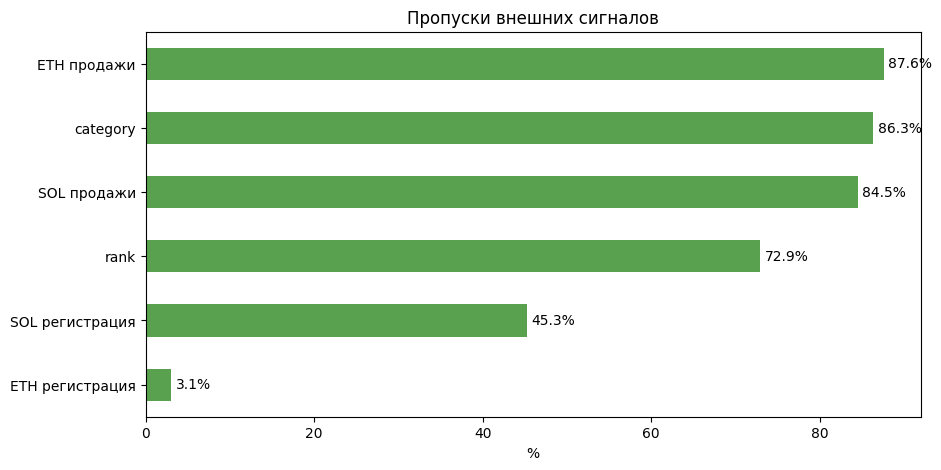

In [24]:
missing = pd.Series({
    'ETH регистрация': 100 - df['eth_reg_price'].notna().mean() * 100,
    'ETH продажи': 100 -(df['eth_sales_count'] > 0).mean() * 100,
    'SOL регистрация': 100 - df['sol_reg_price'].notna().mean() * 100,
    'SOL продажи': 100 - (df['sol_sales_count'] > 0).mean() * 100,
    'category': 100 - df['category'].notna().mean() * 100,
    'rank': 100 - (df['rank'] > 0).mean() * 100,
}).sort_values()


ax = missing.plot.barh(color='#59A14F')
plt.title('Пропуски внешних сигналов')
plt.xlabel('%')
for i, v in enumerate(missing):
    plt.text(v + 0.5, i, f'{round(v, 1)}%', va='center')

plt.show()

## Выводы
1. Почти все домены из нашего датасета зарегистрованы в ETH, и больше половины — в SOL. Это логично, т.к. у нас датасет является пересечением TON с объединением ETH + SOL 
2. 27% от зарегистрованных ton доменов входят в рейтинг популярности доменов. 14% имеют категорию. Вполне нормальные значения, значит признаки эти мы добавляли не зря.
3. Большинство доменов не продавались на вторичном рынке. Доля пропусков в ETH и SOL вторичных продажах составляет ~85%

## 2. Целевая переменная

count     69866.00
mean         91.41
std        1873.76
min           0.01
1%            1.00
5%            1.00
25%           1.17
50%           7.46
75%          40.00
95%         199.96
99%         999.97
max      215250.00
Name: ton_price, dtype: float64


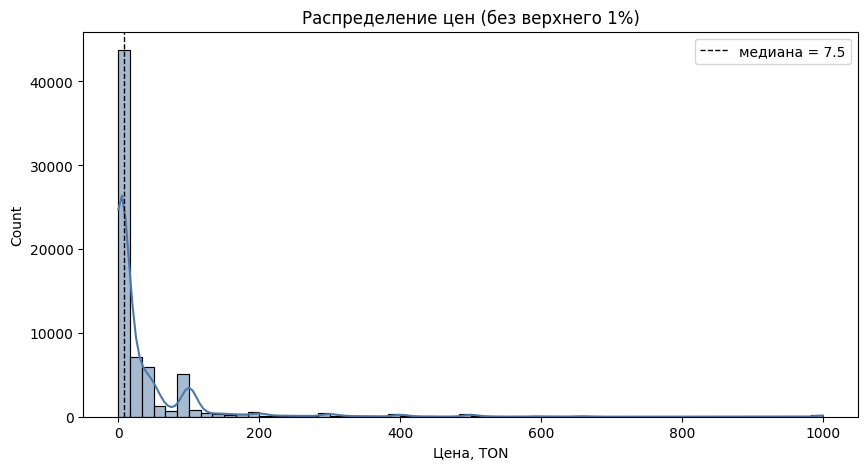

In [25]:
print(df['ton_price'].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).round(2))

cutoff = df['ton_price'].quantile(0.99)
med = df['ton_price'].median()

sns.histplot(df.loc[df['ton_price'] <= cutoff, 'ton_price'], bins=60, kde=True, color='#4E79A7')
plt.axvline(med, color='black', ls='--', lw=1, label=f'медиана = {med:.1f}')
plt.title('Распределение цен (без верхнего 1%)')
plt.xlabel('Цена, TON')
plt.legend()
plt.show()

Абсолютное большинство доменов дешёвые, а небольшая часть дорогих сильно смещает среднее. В дальнейшем лучше ориентироваться на медиану и лог-шкалу вместо линейной.

## 3. Длина, rank и внешние сигналы

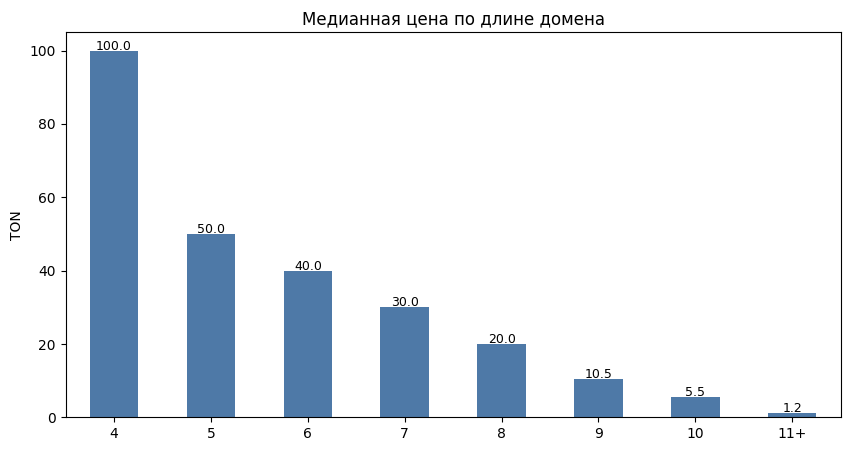

In [ ]:
length_med = df.groupby('length_group', observed=True)['ton_price'].median().reindex(length_order).dropna()
ax = length_med.plot.bar(color='#4E79A7')
ax.set_title('Медианная цена по длине домена')
ax.set_ylabel('TON')
ax.set_xlabel('Длина домена')
for i, v in enumerate(length_med):
    ax.text(i, v + 0.3, f'{v:.1f}', ha='center', fontsize=9)
ax.tick_params(axis='x', rotation=0)
plt.show()

Медианная цена сильно отличается в зависимости от длины домена. Это связано с тем, что минимальная цена регистрации домена в блокчейне TON зависит отличается для доменов разной длины

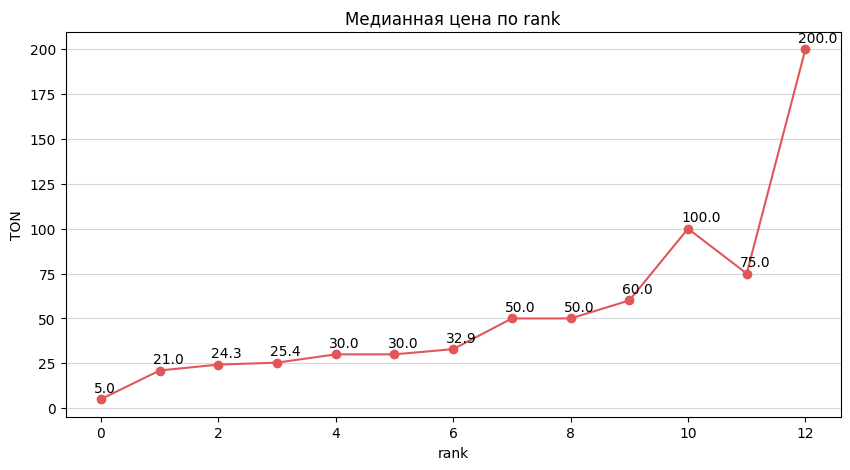

In [50]:
rank_data = df.groupby('rank')['ton_price'].agg(['median', 'size'])
ax = rank_data['median'].plot(marker='o', color='#E15759')
ax.set_title('Медианная цена по rank')
ax.set_xlabel('rank')
ax.set_ylabel('TON')
for i, (rank, median) in enumerate(rank_data['median'].items()):
    ax.annotate(f'{round(median, 1)}', xy=(rank, median), xytext=(-5, 5), textcoords='offset points')
ax.grid(axis='y', alpha=0.5)


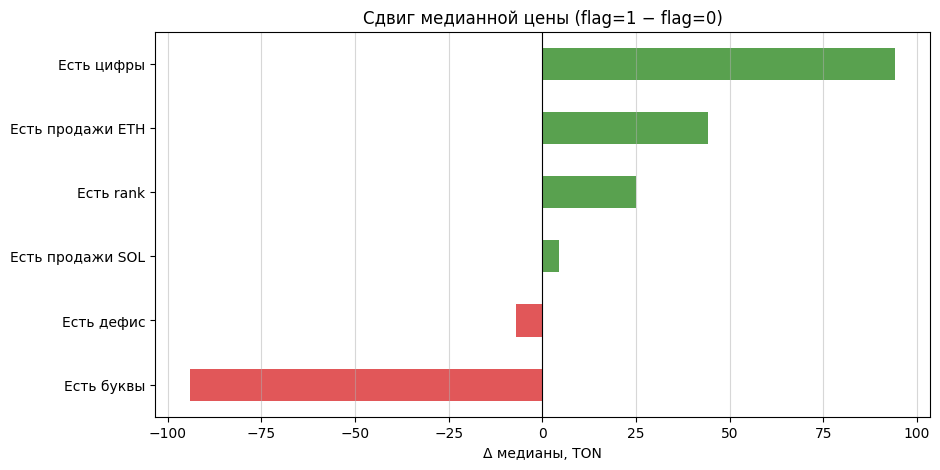

In [ ]:
flags = {'has_letter': 'Есть буквы', 'has_digit': 'Есть цифры', 'has_hyphen': 'Есть дефис'}
deltas = {}
for col, label in flags.items():
    med = df.groupby(col)['ton_price'].median()
    if 0 in med.index and 1 in med.index:
        deltas[label] = med[1] - med[0]

for mask, label in [
    (df['eth_sales_count'] > 0, 'Есть продажи ETH'),
    (df['sol_sales_count'] > 0, 'Есть продажи SOL'),
    (df['rank'] > 0, 'Есть rank'),
]:
    med = df.groupby(mask.astype(int))['ton_price'].median()
    deltas[label] = med[1] - med[0]

deltas = pd.Series(deltas).sort_values()
colors = ['#E15759' if v < 0 else '#59A14F' for v in deltas]
ax = deltas.plot.barh(color=colors)
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Сдвиг медианной цены (flag=1 − flag=0)')
ax.set_xlabel('Изменение медианы, TON')
ax.grid(axis='x', alpha=0.5)
plt.show()

Здесь мы сравнили влияние конкретных бинарных признаках при **прочих равных данных**.
Домены с rank и продажами в eth, а также домены только из цифр более дорогие. 

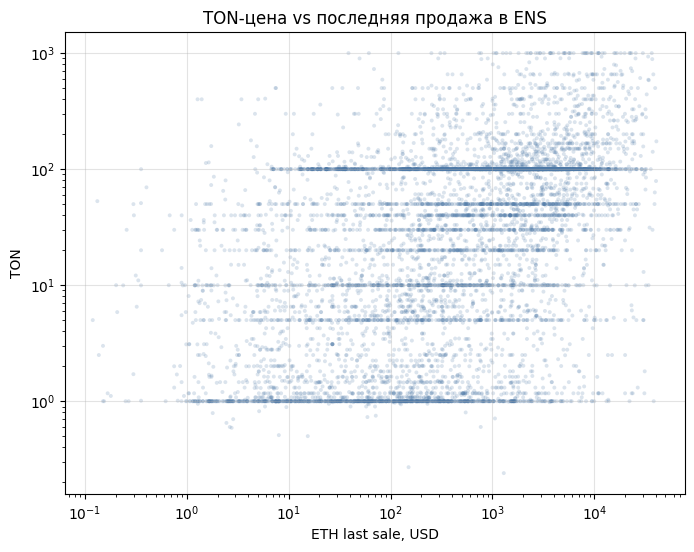

In [ ]:
plot_df = df[['eth_last_sale_price_usd', 'ton_price']].copy()
plot_df = plot_df[(plot_df > 0.1).all(axis=1)]
q99 = plot_df.quantile(0.99)
plot_df = plot_df[(plot_df <= q99).all(axis=1)]
plt.figure(figsize=(8, 6))
plt.scatter(
    plot_df['eth_last_sale_price_usd'],
    plot_df['ton_price'],
    s=8, alpha=0.2, color='#4E79A7', edgecolors='none'
)
plt.xscale('log')
plt.yscale('log')
plt.title('TON-цена vs последняя продажа в ETH')
plt.xlabel('ETH last sale, USD')
plt.ylabel('TON')
plt.grid(alpha=0.35)
plt.show()

Мы видим, что тон цена зависит от цены продажи в Ethereum 

## 4. Корреляции

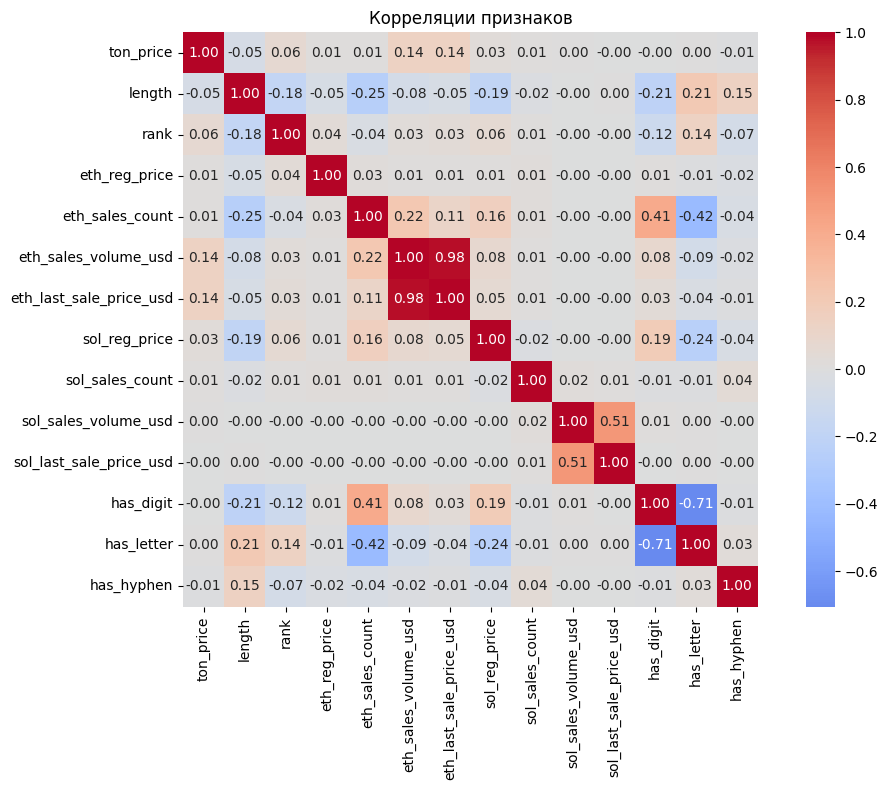

In [56]:
corr_cols = [
    'ton_price', 'length', 'rank',
    'eth_reg_price', 'eth_sales_count', 'eth_sales_volume_usd', 'eth_last_sale_price_usd',
    'sol_reg_price', 'sol_sales_count', 'sol_sales_volume_usd', 'sol_last_sale_price_usd',
    'has_digit', 'has_letter', 'has_hyphen'
]
corr = df[corr_cols].corr()
plt.figure(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Корреляции признаков')
plt.tight_layout()
plt.show()

По ранговой корреляции лучше видно монотонные связи в скошенных распределениях: сильнее всего с целевой переменной связаны длина, популярность и сигналы вторичных продаж.

## 5. Категории

In [32]:
top_cats = df['category'].value_counts().head(8).index
cat_df = df[df['category'].isin(top_cats)]
cat_stats = cat_df.groupby('category')['ton_price'].agg(['size', 'median']).reindex(top_cats)
sorted_med = cat_stats.sort_values('median')['median']

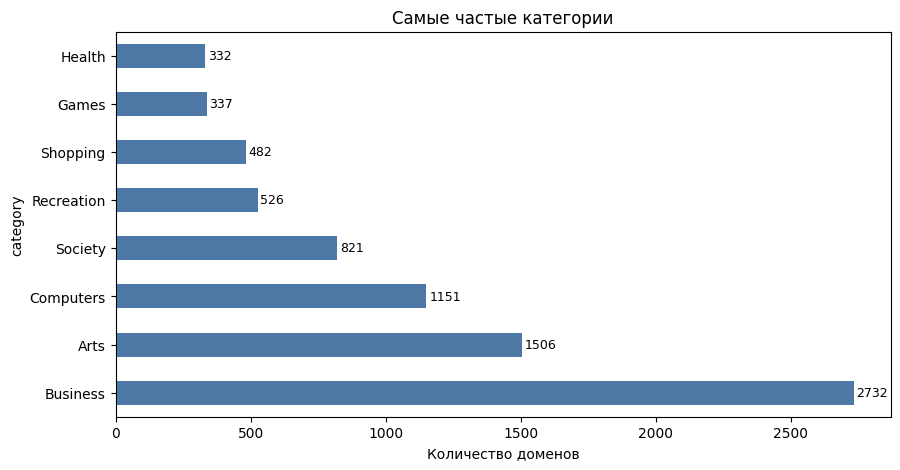

In [33]:
ax = cat_stats['size'].plot.barh(color='#4E79A7')
ax.set_title('Самые частые категории')
ax.set_xlabel('Количество доменов')
for i, v in enumerate(cat_stats['size']):
    ax.text(v + 10, i, str(v), va='center', fontsize=9)
plt.show()

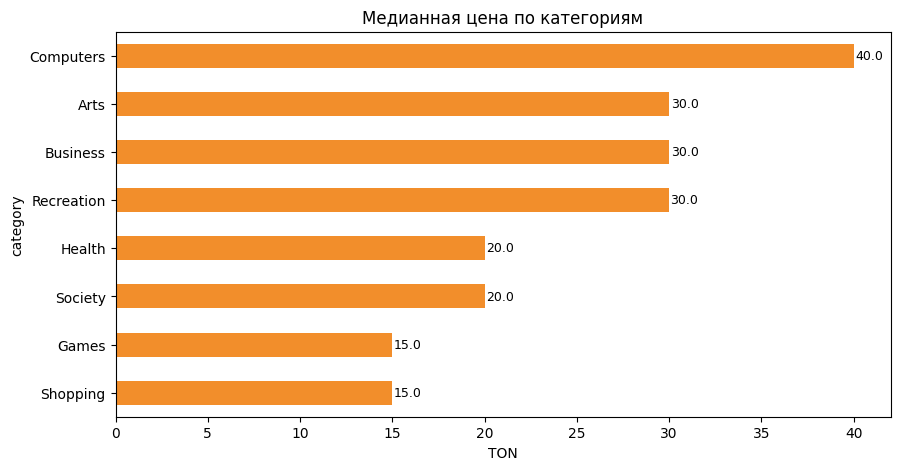

In [34]:
ax = sorted_med.plot.barh(color='#F28E2B')
ax.set_title('Медианная цена по категориям')
ax.set_xlabel('TON')
for i, v in enumerate(sorted_med):
    ax.text(v + 0.1, i, f'{v:.1f}', va='center', fontsize=9)
plt.show()

Мы видим, что хоть "покрытие признака" категории слабое, но оно сильно влияет на медианную цену. Если домен используется в web2 и имеет размеченную категорию, то он скорее всего будет цениться дороже 